# Exercise 1: 
### Hierarchical Clustering (Agglomerative)

For this exercise, we will be using the `Mall_Customers.csv` dataset which can be found on Kaggle, https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

Your task is to prepare/clean the data in `Mall_Customers.csv` and subsequently the cleaned dataset is to be used in the agglomerative clustering training process.

---

#### Load libraries
Load the necessary libraries for this exercise.

In [1]:
# import necessary libraries
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

#### Data Preparation / Preprocessing
Perform the necessary preprocessing steps.

In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
iloced_df = df.iloc[:,2:5]
iloced_df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


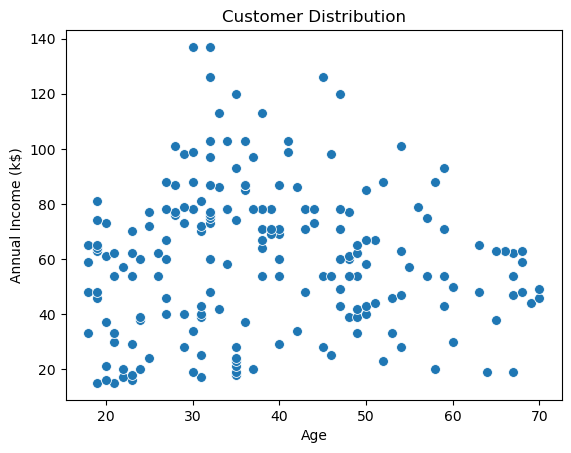

In [5]:
sns.scatterplot(
    x=iloced_df["Age"], y=iloced_df["Annual Income (k$)"], s=50
)
plt.title("Customer Distribution")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()

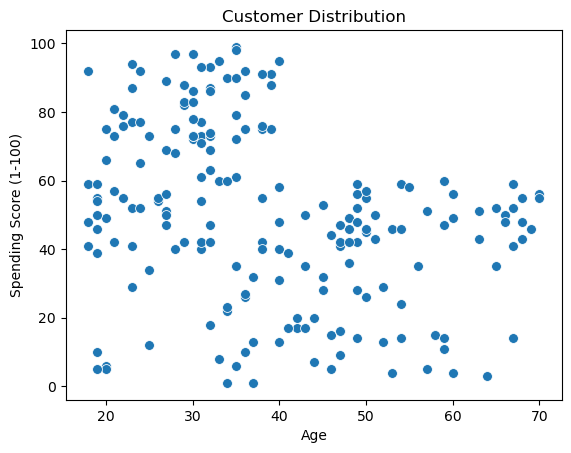

In [6]:
sns.scatterplot(
    x=iloced_df["Age"], y=iloced_df["Spending Score (1-100)"], s=50
)
plt.title("Customer Distribution")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

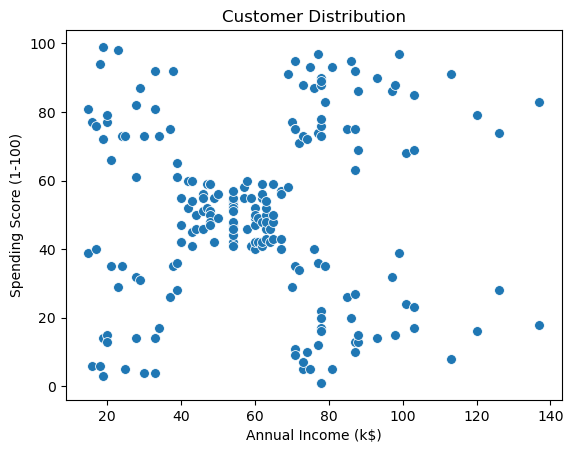

In [7]:
sns.scatterplot(
    x=iloced_df["Annual Income (k$)"], y=iloced_df["Spending Score (1-100)"], s=50
)
plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

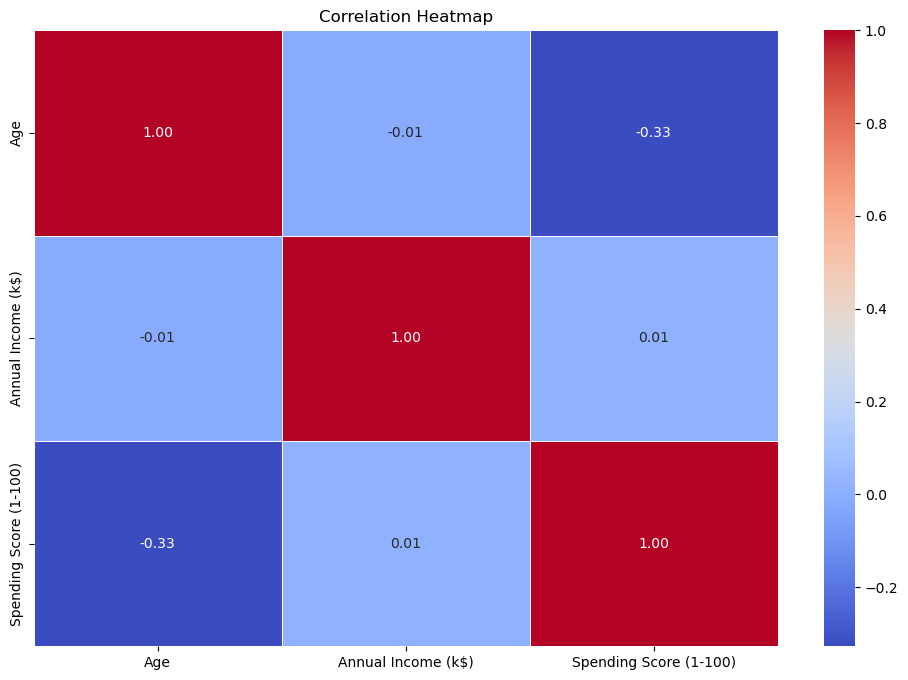

In [8]:
correlation_matrix = iloced_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
iloced_df = df.iloc[:,3:5]
iloced_df

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [10]:
stdscaler = StandardScaler()

stdscaler.fit(iloced_df)

transformed_df = stdscaler.transform(iloced_df)

scaled_df = pd.DataFrame(transformed_df, columns=iloced_df.columns)
scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


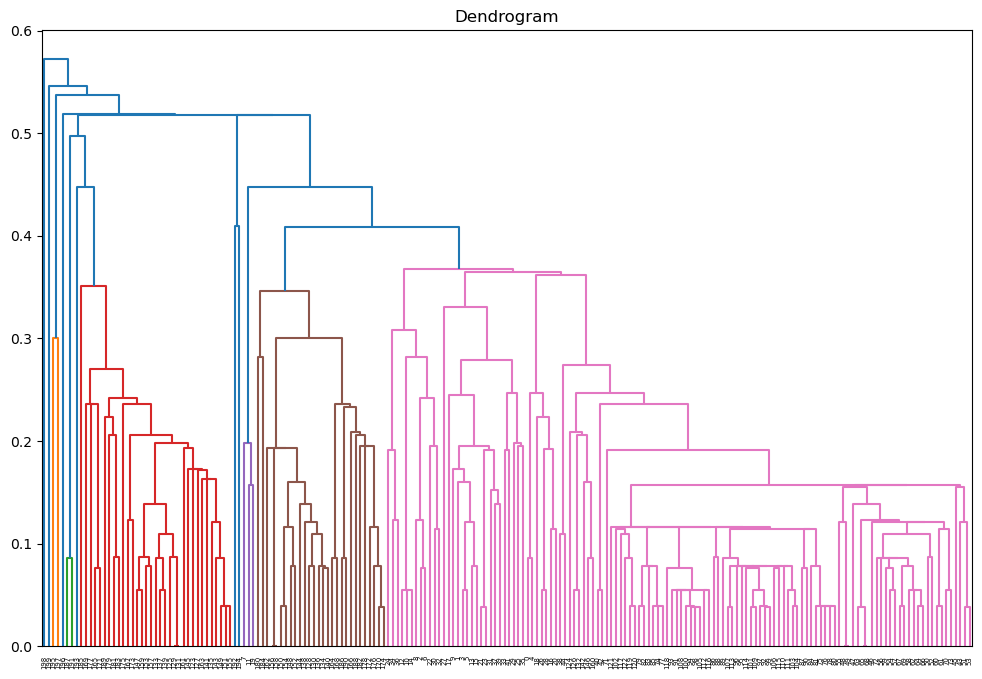

In [11]:
plt.figure(figsize=(12,8))
plt.title("Dendrogram")
dend = dendrogram(linkage(scaled_df, method="single"))

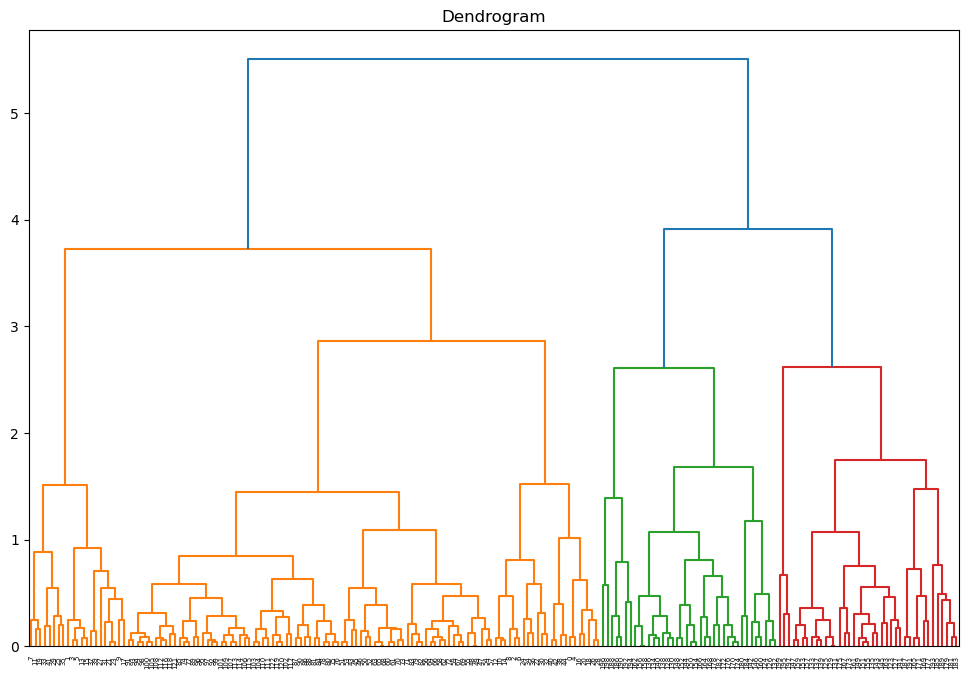

In [12]:
plt.figure(figsize=(12,8))
plt.title("Dendrogram")
dend = dendrogram(linkage(scaled_df, method="complete"))

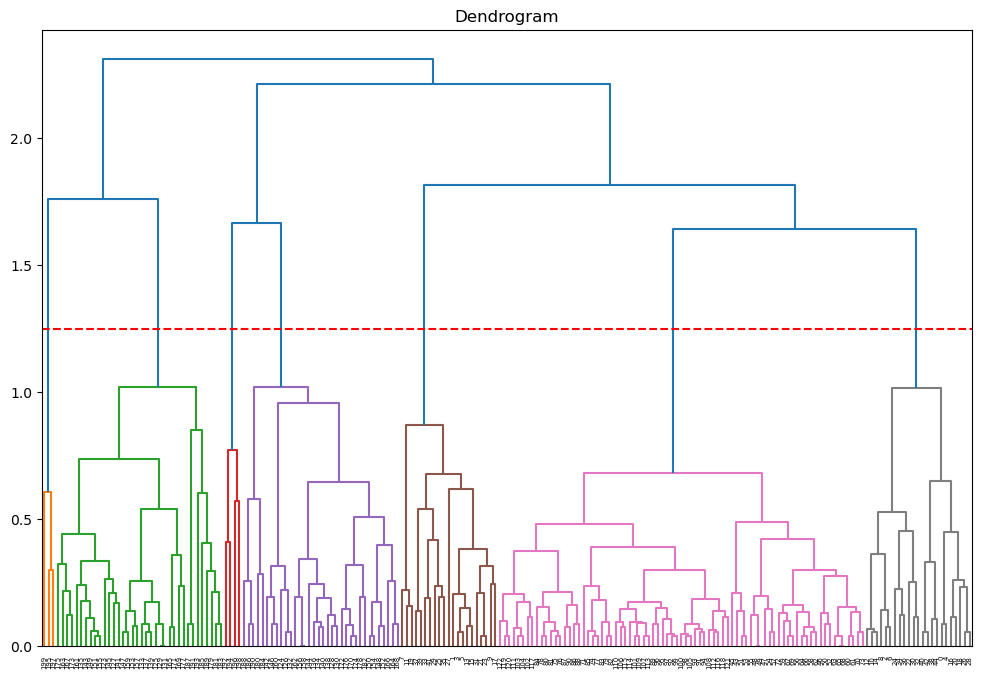

In [13]:
plt.figure(figsize=(12,8))
plt.title("Dendrogram")
dend = dendrogram(linkage(scaled_df, method="average"))
# 7 clusters looks like a good number
plt.axhline(y=1.25, color='r', linestyle="--")

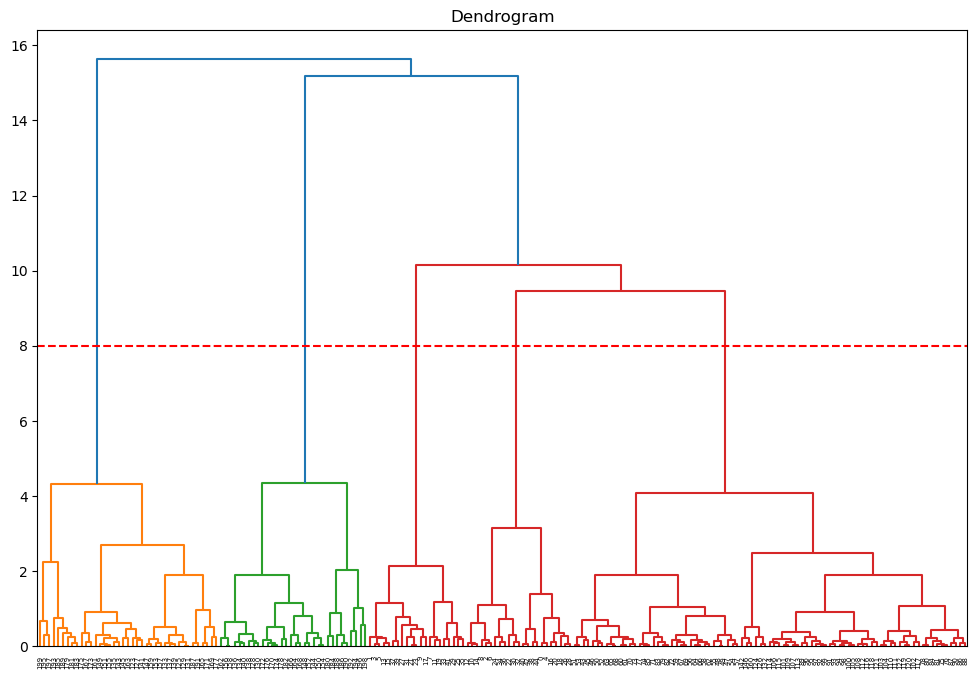

In [14]:
plt.figure(figsize=(12,8))
plt.title("Dendrogram")
dend = dendrogram(linkage(scaled_df, method="ward"))
# 5 clusters looks like a good number
plt.axhline(y=8, color='r', linestyle="--")

#### Model Training

In [15]:
agglo_cluster = AgglomerativeClustering(n_clusters=7, metric="euclidean", linkage="average")
agglo_cluster.fit_predict(scaled_df)

array([1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 6,
       1, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 5, 2, 5, 4, 5, 4,
       5, 4], dtype=int64)

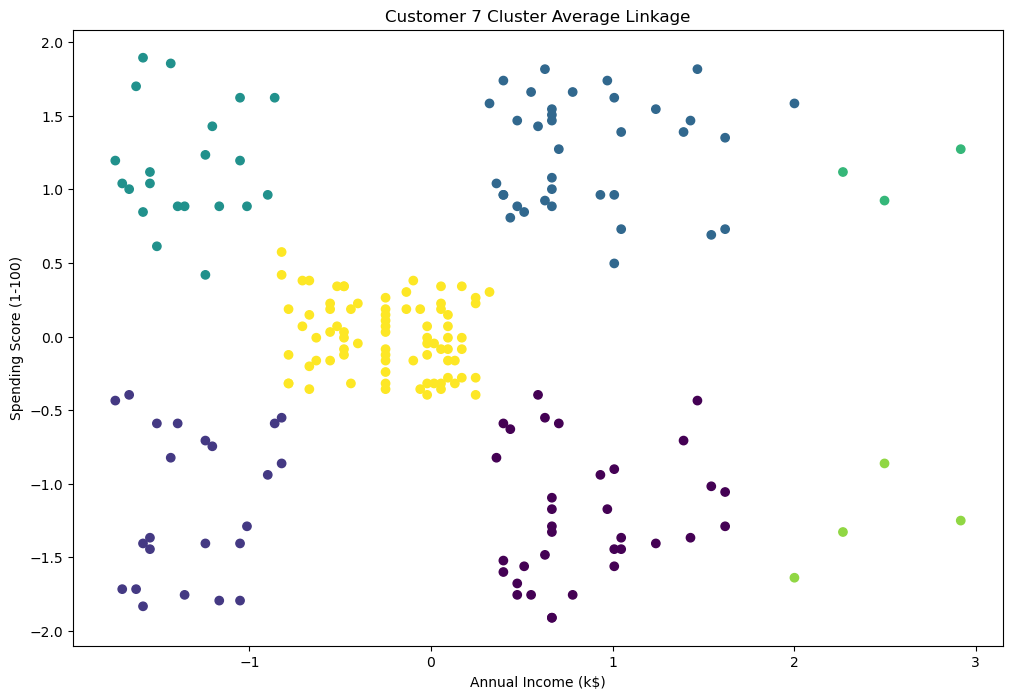

In [16]:
plt.figure(figsize=(12,8))
plt.title("Customer 7 Cluster Average Linkage")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.scatter(scaled_df['Annual Income (k$)'],scaled_df['Spending Score (1-100)'], c=agglo_cluster.labels_)

In [17]:
agglo_cluster = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
agglo_cluster.fit_predict(scaled_df)

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int64)

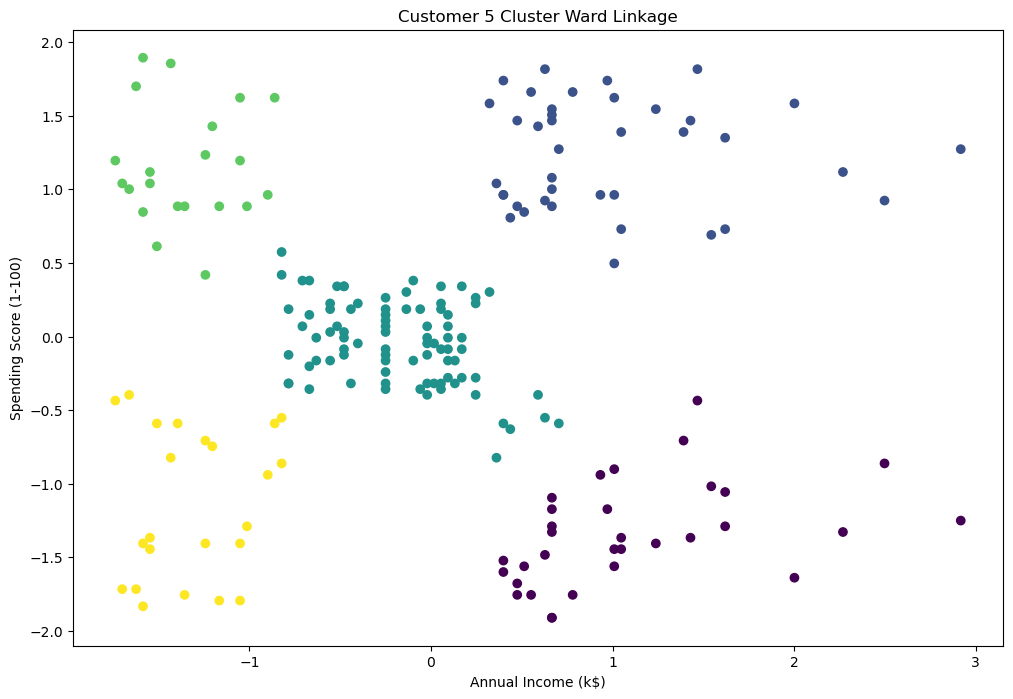

In [18]:
plt.figure(figsize=(12,8))
plt.title("Customer 5 Cluster Ward Linkage")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.scatter(scaled_df['Annual Income (k$)'],scaled_df['Spending Score (1-100)'], c=agglo_cluster.labels_)

#### Conclusion / Answer

Ameen: I feel that the ward linkage with 5 clusters is a better answer.